Running simulation...
  step 0/700
  step 150/700
  step 300/700
  step 450/700
  step 600/700
Generated frames: 140
Building animation...
Saving GIF...
Done: galaxy_collision.gif


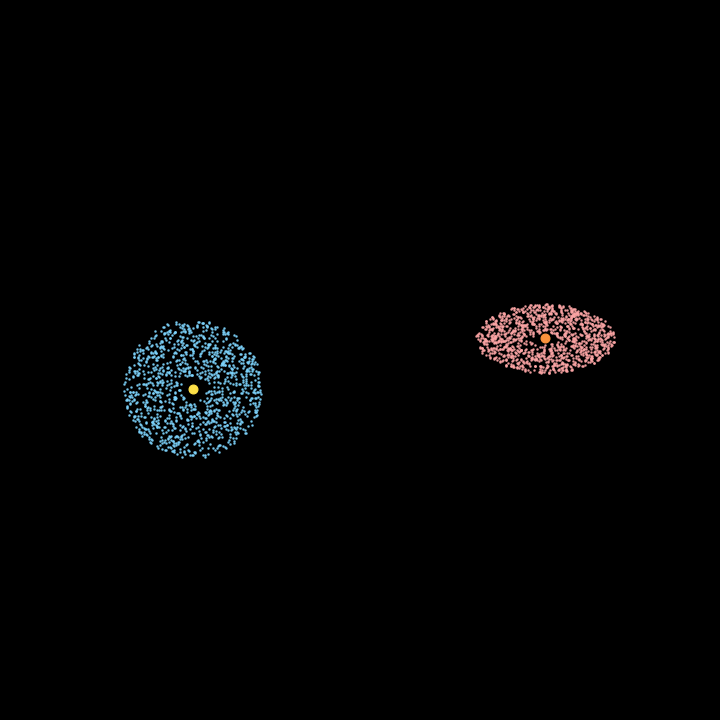

In [1]:
# Simple Galaxy Collision Simulation 3

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

# ============================================================
# Settings
# ============================================================
np.random.seed(7)

FAST_MODE = True

if FAST_MODE:
    N1 = 1200
    N2 = 1200
    N_STEPS = 700
    SAVE_EVERY = 5
    DPI = 90
else:
    N1 = 2000
    N2 = 2000
    N_STEPS = 1200
    SAVE_EVERY = 4
    DPI = 120

G = 1.0
DT = 0.05
SOFTEN = 0.15

M1 = 1.0
M2 = 1.0

DISK_RMIN_1 = 1.0
DISK_RMAX_1 = 5.5
INCLINATION_1 = 0.0

DISK_RMIN_2 = 1.0
DISK_RMAX_2 = 5.5
INCLINATION_2 = np.pi / 3

INITIAL_SEP = 28.0
IMPACT_PARAM = 4.0
APPROACH_VEL = 0.55

OUTPUT_FILE = "galaxy_collision.gif"
FIG_SIZE = (8, 8)
VIEW_LIMIT = 22


# ============================================================
# Create a galaxy disk
# ============================================================
def make_disk(core_pos, core_vel, M_core, N, rmin, rmax, inclination):
    """
    Create a simple disk of massless stars around one massive core.
    The stars begin on circular orbits.
    """

    r = np.sqrt(np.random.uniform(rmin**2, rmax**2, N))
    theta = np.random.uniform(0, 2 * np.pi, N)

    x = r * np.cos(theta)
    y = r * np.sin(theta)
    z = np.zeros(N)

    v_circ = np.sqrt(G * M_core / r)

    vx = -v_circ * np.sin(theta)
    vy =  v_circ * np.cos(theta)
    vz = np.zeros(N)

    pos = np.column_stack([x, y, z])
    vel = np.column_stack([vx, vy, vz])

    # Tilt the disk if needed
    if inclination != 0:
        c, s = np.cos(inclination), np.sin(inclination)

        R = np.array([
            [1, 0, 0],
            [0, c, -s],
            [0, s,  c],
        ])

        pos = pos @ R.T
        vel = vel @ R.T

    pos += core_pos
    vel += core_vel

    return pos, vel


# ============================================================
# Gravity functions
# ============================================================
def particle_accel(pos, c1, c2):
    """
    Stars feel gravity from both galaxy cores.
    Stars do not attract each other.
    This keeps the simulation lightweight.
    """

    r1 = c1 - pos
    d1 = (np.sum(r1**2, axis=1) + SOFTEN**2) ** 1.5
    a1 = G * M1 * r1 / d1[:, None]

    r2 = c2 - pos
    d2 = (np.sum(r2**2, axis=1) + SOFTEN**2) ** 1.5
    a2 = G * M2 * r2 / d2[:, None]

    return a1 + a2


def core_accel(c1, c2):
    """
    Mutual gravity between the two galaxy cores.
    """

    r = c2 - c1
    d = (np.sum(r**2) + SOFTEN**2) ** 1.5

    a_on_1 =  G * M2 * r / d
    a_on_2 = -G * M1 * r / d

    return a_on_1, a_on_2


# ============================================================
# Initial setup
# ============================================================
c1 = np.array([-INITIAL_SEP / 2, -IMPACT_PARAM / 2, 0.0])
c2 = np.array([ INITIAL_SEP / 2,  IMPACT_PARAM / 2, 0.0])

v1 = np.array([ APPROACH_VEL / 2, 0.0, 0.0])
v2 = np.array([-APPROACH_VEL / 2, 0.0, 0.0])

pos1, vel1 = make_disk(
    c1, v1, M1, N1,
    DISK_RMIN_1,
    DISK_RMAX_1,
    INCLINATION_1
)

pos2, vel2 = make_disk(
    c2, v2, M2, N2,
    DISK_RMIN_2,
    DISK_RMAX_2,
    INCLINATION_2
)

positions = np.vstack([pos1, pos2])
velocities = np.vstack([vel1, vel2])

galaxy_id = np.concatenate([
    np.zeros(N1, dtype=int),
    np.ones(N2, dtype=int)
])

mask1 = galaxy_id == 0
mask2 = galaxy_id == 1


# ============================================================
# Run simulation
# ============================================================
frames = []
core_frames = []

print("Running simulation...")

for step in range(N_STEPS):

    # Leapfrog integration
    a_p = particle_accel(positions, c1, c2)
    a_c1, a_c2 = core_accel(c1, c2)

    velocities += a_p * DT / 2
    v1 += a_c1 * DT / 2
    v2 += a_c2 * DT / 2

    positions += velocities * DT
    c1 += v1 * DT
    c2 += v2 * DT

    a_p = particle_accel(positions, c1, c2)
    a_c1, a_c2 = core_accel(c1, c2)

    velocities += a_p * DT / 2
    v1 += a_c1 * DT / 2
    v2 += a_c2 * DT / 2

    if step % SAVE_EVERY == 0:
        frames.append(positions.copy())
        core_frames.append((c1.copy(), c2.copy()))

    if step % 150 == 0:
        print(f"  step {step}/{N_STEPS}")

print(f"Generated frames: {len(frames)}")


# ============================================================
# Animation
# ============================================================
print("Building animation...")

fig, ax = plt.subplots(figsize=FIG_SIZE, facecolor="black")
ax.set_facecolor("black")
ax.set_xlim(-VIEW_LIMIT, VIEW_LIMIT)
ax.set_ylim(-VIEW_LIMIT, VIEW_LIMIT)
ax.set_aspect("equal")
ax.axis("off")

# Two galaxies in different colours
scat1 = ax.scatter(
    frames[0][mask1, 0],
    frames[0][mask1, 1],
    c="#7DD3FC",
    s=1.2,
    alpha=0.75
)

scat2 = ax.scatter(
    frames[0][mask2, 0],
    frames[0][mask2, 1],
    c="#FCA5A5",
    s=1.2,
    alpha=0.75
)

# Bright galaxy cores
core1_dot, = ax.plot(
    [],
    [],
    "o",
    color="#FDE047",
    markersize=7,
    zorder=5
)

core2_dot, = ax.plot(
    [],
    [],
    "o",
    color="#FB923C",
    markersize=7,
    zorder=5
)


def update(i):
    scat1.set_offsets(frames[i][mask1, :2])
    scat2.set_offsets(frames[i][mask2, :2])

    cc1, cc2 = core_frames[i]

    core1_dot.set_data([cc1[0]], [cc1[1]])
    core2_dot.set_data([cc2[0]], [cc2[1]])

    return scat1, scat2, core1_dot, core2_dot


anim = FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=40,
    blit=True
)

print("Saving GIF...")

anim.save(
    OUTPUT_FILE,
    writer=PillowWriter(fps=25),
    savefig_kwargs={"facecolor": "black"},
    dpi=DPI
)

plt.close(fig)

print("Done:", OUTPUT_FILE)
display(Image(filename=OUTPUT_FILE))